# Advanced USD (Universal Scene Description) Tutorial

**Comprehensive Guide to Advanced USD Operations for Computer Graphics**

*Author: Elements Framework Team*  
*Version: 2.0*  
*Date: November 2025*  
*Target: Advanced Computer Graphics Students & Professionals*

---

## 📚 Prerequisites

Before starting this tutorial, you should have completed:
- **basicUSD.ipynb** - Basic USD concepts and operations
- Understanding of 3D graphics fundamentals (transforms, meshes, materials)
- Python programming experience
- Familiarity with Blender or similar 3D software

## 🎯 Learning Objectives

By the end of this tutorial, you will be able to:
- ✅ Master advanced USD composition and layering techniques
- ✅ Build complex character rigs and animation systems
- ✅ Create production-ready asset pipelines
- ✅ Optimize USD scenes for performance
- ✅ Integrate USD with rendering and simulation workflows
- ✅ Implement procedural content generation techniques

## 📋 Tutorial Structure

This tutorial covers **7 priority areas** with **37 sections** total:

---

## 📋 Table of Contents

### 🔷 **Priority 1: Core Operations** (4 sections)
- **Section 12:** [Querying Stage and Prims](#section-12-querying-stage-and-prims)
- **Section 13:** [Reading and Modifying Attributes](#section-13-reading-and-modifying-attributes)  
- **Section 14:** [Working with Relationships](#section-14-working-with-relationships)
- **Section 15:** [Prims and Paths](#section-15-prims-and-paths)

### 🔷 **Priority 2: Scene Composition** (5 sections)
- **Section 16:** [Layer Composition and Sublayers](#section-16-layer-composition-and-sublayers)
- **Section 17:** [References (External Assets)](#section-17-references-external-assets)
- **Section 18:** [Payloads (Lazy Loading)](#section-18-payloads-lazy-loading)
- **Section 19:** [Variants and VariantSets](#section-19-variants-and-variantsets)
- **Section 21:** [Inherit and Specialize](#section-21-inherit-and-specialize)

### 🔷 **Priority 3: Rendering** (4 sections)
- **Section 22:** [Materials and Shading (UsdShade)](#section-22-materials-and-shading-usdshade)
- **Section 24:** [Textures and UV Mapping](#section-24-textures-and-uv-mapping)
- **Section 25:** [Cameras and Framing](#section-25-cameras-and-framing)
- **Section 26:** [Lighting (UsdLux)](#section-26-lighting-usdlux)

### 🔷 **Priority 4: Advanced Character Animation** (5 sections)
- **Section 27:** [Complete Character Rig (Humanoid)](#section-27-complete-character-rig-humanoid)
- **Section 28:** [Skinning Weights](#section-28-skinning-weights)
- **Section 29:** [Blend Shapes (Facial Animation)](#section-29-blend-shapes-facial-animation)
- **Section 30:** [Animation Curves and Retargeting](#section-30-animation-curves-and-retargeting)
- **Section 31:** [Physics and Simulation (UsdPhysics)](#section-31-physics-and-simulation-usdphysics)

### 🔷 **Priority 5: Workflows** (3 sections)
- **Section 32:** [Blender Integration (Import/Export)](#section-32-blender-integration-importexport)
- **Section 33:** [Rendering with Hydra Delegates](#section-33-rendering-with-hydra-delegates)
- **Section 34:** [Asset Pipeline Best Practices](#section-34-asset-pipeline-best-practices)

### 🔷 **Priority 6: Advanced Topics** (3 sections)
- **Section 35:** [Procedural Generation](#section-35-procedural-generation)
- **Section 36:** [Volume Rendering (VDB)](#section-36-volume-rendering-vdb)
- **Section 37:** [Performance Optimization](#section-37-performance-optimization)

### 🔷 **Priority 7: Appendices** (6 sections)
- **Appendix A:** [Complete Installation Guide](#appendix-a-complete-installation-guide)
- **Appendix B:** [USD Tools Reference](#appendix-b-usd-tools-reference)
- **Appendix C:** [Python API Quick Reference](#appendix-c-python-api-quick-reference)
- **Appendix D:** [USDA Syntax Cheatsheet](#appendix-d-usda-syntax-cheatsheet)
- **Appendix E:** [Performance Best Practices](#appendix-e-performance-best-practices)
- **Appendix F:** [Learning Resources and Documentation](#appendix-f-learning-resources-and-documentation)

---

## 🚀 Environment Setup and Library Imports

### What You'll Learn:
- Import advanced USD Python modules
- Set up working directories for complex scenes
- Configure USD composition settings
- Establish debugging and profiling tools

### Required USD Modules:
- **pxr.Usd** - Core USD functionality
- **pxr.UsdGeom** - Geometric schemas
- **pxr.UsdShade** - Shading and materials
- **pxr.UsdSkel** - Skeletal animation
- **pxr.UsdLux** - Lighting
- **pxr.UsdPhysics** - Physics simulation
- **pxr.Sdf** - Scene description foundation
- **pxr.Gf** - Graphics foundation (math)
- **pxr.Vt** - Value types
- **pxr.Ar** - Asset resolution
- **pxr.Plug** - Plugin system

In [1]:
# Advanced USD Environment Setup
import sys
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple

# Core USD imports
try:
    from pxr import Usd, UsdGeom, UsdShade, UsdSkel, UsdLux, UsdPhysics
    from pxr import Sdf, Gf, Vt, Tf, Ar, Plug, Kind, Work
    from pxr import UsdUtils, UsdRender
    print("✅ All USD modules imported successfully!")
except ImportError as e:
    print(f"❌ USD import failed: {e}")
    print("Please install USD: pip install usd-core")
    sys.exit(1)

# Additional Python libraries for advanced operations
try:
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyBboxPatch, ConnectionPatch
    print("✅ Additional libraries imported successfully!")
except ImportError as e:
    print(f"⚠️  Optional libraries missing: {e}")
    print("Some visualization features may be limited")

# Environment Information
print("="*60)
print("🔧 ADVANCED USD ENVIRONMENT")
print("="*60)
print(f"Python Version: {sys.version}")
print(f"USD Version: {Usd.GetVersion()}")
print(f"Working Directory: {os.getcwd()}")
print(f"Platform: {sys.platform}")
print("="*60)

✅ All USD modules imported successfully!
✅ Additional libraries imported successfully!
🔧 ADVANCED USD ENVIRONMENT
Python Version: 3.10.18 (main, Jun  5 2025, 08:37:47) [Clang 14.0.6 ]
USD Version: (0, 25, 11)
Working Directory: /Users/papagian/GPcode/Elements/Elements/pyEEL/notebooks/CG
Platform: darwin


In [2]:
# Advanced USD Utilities and Helper Functions
class AdvancedUSDUtils:
    """Utility class for advanced USD operations"""
    
    def __init__(self, output_dir: str = "advanced_usd_output"):
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)
        self.stages = {}  # Cache for opened stages
        self.performance_log = []
        
        print(f"📁 Output directory: {self.output_dir.absolute()}")
    
    def create_stage(self, filename: str) -> Usd.Stage:
        """Create a new USD stage with advanced settings"""
        filepath = self.output_dir / filename
        
        # Remove existing file if it exists
        if filepath.exists():
            filepath.unlink()
        
        # Create stage in memory first, then export
        stage = Usd.Stage.CreateInMemory()
        
        # Export to file
        stage.Export(str(filepath))
        
        # Set up stage metadata
        stage.SetMetadata('upAxis', 'Y')
        stage.SetMetadata('metersPerUnit', 1.0)
        stage.SetMetadata('timeCodesPerSecond', 24.0)
        stage.SetFramesPerSecond(24.0)
        stage.SetStartTimeCode(1.0)
        stage.SetEndTimeCode(100.0)
        
        # Cache the stage
        self.stages[filename] = stage
        return stage
    
    def save_stage(self, stage: Usd.Stage, show_content: bool = True) -> None:
        """Save stage and optionally display content"""
        try:
            stage.GetRootLayer().Save()
            filepath = stage.GetRootLayer().realPath
        except:
            # Stage is in memory, already exported in create_stage
            filepath = "in-memory stage"
        
        if show_content:
            print(f"\n💾 Stage saved: {Path(str(filepath)).name if filepath != 'in-memory stage' else filepath}")
            self.show_stage_tree(stage)
    
    def show_stage_tree(self, stage: Usd.Stage, max_depth: int = 3) -> None:
        """Display stage hierarchy with advanced information"""
        print("\n🌳 Stage Hierarchy:")
        print("=" * 50)
        
        def print_prim(prim: Usd.Prim, depth: int = 0, prefix: str = ""):
            if depth > max_depth:
                return
            
            indent = "  " * depth
            type_name = prim.GetTypeName()
            
            # Get composition info
            composition_info = ""
            pcp_prim_index = prim.GetPrimIndex()
            if pcp_prim_index.HasArcs():
                arc_types = [str(arc.GetArcType()) for arc in pcp_prim_index.primStack[:3]]
                composition_info = f" [{', '.join(arc_types)}]"
            
            # Show prim info
            icon = "📁" if prim.GetChildren() else "📄"
            print(f"{indent}{prefix}{icon} /{prim.GetPath().pathString} ({type_name}){composition_info}")
            
            # Show key attributes
            if depth < 2:  # Don't show attributes too deep
                for attr in prim.GetAttributes()[:3]:  # Limit to first 3
                    value = attr.Get()
                    if value is not None:
                        value_str = str(value)[:50] + ("..." if len(str(value)) > 50 else "")
                        print(f"{indent}  📝 {attr.GetName()}: {value_str}")
            
            # Recurse to children
            if depth < max_depth:
                children = prim.GetChildren()
                for i, child in enumerate(children):
                    is_last = i == len(children) - 1
                    child_prefix = "└── " if is_last else "├── "
                    print_prim(child, depth + 1, child_prefix)
        
        print_prim(stage.GetPseudoRoot())
        print("=" * 50)
    
    def create_hierarchy_diagram(self, stage: Usd.Stage, title: str = "USD Stage Hierarchy"):
        """Create a visual diagram of the USD stage hierarchy"""
        try:
            fig, ax = plt.subplots(figsize=(12, 8))
            ax.set_xlim(0, 10)
            ax.set_ylim(0, 10)
            ax.axis('off')
            
            # Title
            ax.text(5, 9.5, title, fontsize=16, fontweight='bold', ha='center')
            
            # Collect hierarchy data
            hierarchy_data = []
            
            def collect_hierarchy(prim: Usd.Prim, level: int = 0, parent_pos: Tuple[float, float] = None):
                if level > 3:  # Limit depth for visualization
                    return
                
                # Position calculation
                x = 1 + level * 2
                y = 8 - len(hierarchy_data) * 0.8
                
                # Prim info
                type_name = prim.GetTypeName() or "Prim"
                name = prim.GetName() or "Root"
                
                hierarchy_data.append({
                    'name': name,
                    'type': type_name,
                    'level': level,
                    'pos': (x, y),
                    'parent_pos': parent_pos
                })
                
                # Draw prim box
                box = FancyBboxPatch(
                    (x - 0.4, y - 0.2), 0.8, 0.4,
                    boxstyle="round,pad=0.02",
                    facecolor='lightblue' if type_name else 'lightgray',
                    edgecolor='black',
                    linewidth=1
                )
                ax.add_patch(box)
                
                # Draw prim text
                ax.text(x, y, f"{name}\n({type_name})", ha='center', va='center', fontsize=8, fontweight='bold')
                
                # Draw connection to parent
                if parent_pos:
                    connection = ConnectionPatch(
                        parent_pos, (x, y),
                        "data", "data",
                        arrowstyle="->",
                        shrinkA=5, shrinkB=5,
                        color='gray',
                        linewidth=1
                    )
                    ax.add_patch(connection)
                
                # Process children
                for child in prim.GetChildren():
                    collect_hierarchy(child, level + 1, (x, y))
            
            collect_hierarchy(stage.GetPseudoRoot())
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"⚠️ Could not create hierarchy diagram: {e}")
            print("Falling back to text representation...")
    
    def profile_operation(self, operation_name: str):
        """Decorator for profiling USD operations"""
        def decorator(func):
            def wrapper(*args, **kwargs):
                start_time = time.time()
                result = func(*args, **kwargs)
                end_time = time.time()
                
                duration = end_time - start_time
                self.performance_log.append({
                    'operation': operation_name,
                    'duration': duration,
                    'timestamp': time.time()
                })
                
                print(f"⏱️ {operation_name}: {duration:.3f}s")
                return result
            return wrapper
        return decorator
    
    def show_performance_summary(self):
        """Show performance summary of operations"""
        if not self.performance_log:
            print("No performance data available")
            return
        
        print("\n📊 Performance Summary:")
        print("=" * 40)
        
        total_time = sum(entry['duration'] for entry in self.performance_log)
        print(f"Total Time: {total_time:.3f}s")
        
        for entry in self.performance_log[-5:]:  # Show last 5 operations
            print(f"  {entry['operation']}: {entry['duration']:.3f}s")
        
        print("=" * 40)

# Initialize utilities
usd_utils = AdvancedUSDUtils()
print("🛠️ Advanced USD utilities initialized!")

📁 Output directory: /Users/papagian/GPcode/Elements/Elements/pyEEL/notebooks/CG/advanced_usd_output
🛠️ Advanced USD utilities initialized!


---

## 🔷 Priority 1: Core Operations

The foundation of advanced USD work lies in mastering core operations. These sections cover essential techniques for querying, modifying, and navigating USD scenes programmatically.

---

### Section 12: Querying Stage and Prims

**🎯 Learning Objectives:**
- Master efficient stage traversal techniques
- Use USD predicates for advanced filtering
- Implement custom prim queries
- Understand performance implications of different query methods

**🔍 Key Concepts:**
- **Stage Traversal**: Different ways to iterate through a USD stage
- **Predicates**: Filtering functions for selective prim processing  
- **Prim Queries**: Finding prims by type, attribute, or custom criteria
- **Performance**: Optimizing traversal for large scenes

**🌳 USD Stage Hierarchy Diagram:**

```
USD Stage
├── Root Prim ("/")
│   ├── World
│   │   ├── Characters
│   │   │   ├── Hero (UsdSkel.Root)
│   │   │   └── Crowd (PointInstancer)
│   │   ├── Environment  
│   │   │   ├── Buildings (Xform)
│   │   │   └── Terrain (Mesh)
│   │   └── Effects
│   │       ├── Particles
│   │       └── Volumes
│   ├── Materials
│   │   ├── CharacterMtl (Material)
│   │   └── EnvironmentMtl (Material)
│   └── Lights
│       ├── SunLight (DistantLight)
│       └── SkyDome (DomeLight)
```

🔍 SECTION 12: Querying Stage and Prims
✅ Complex scene created for querying demonstrations


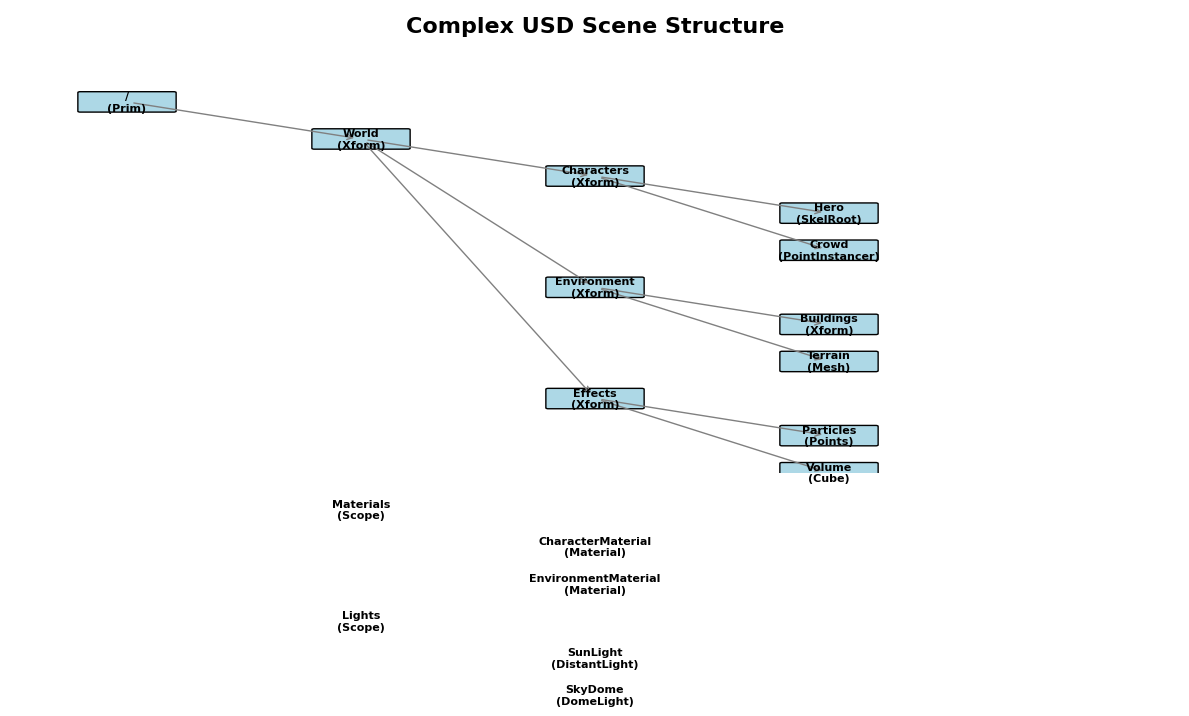

In [3]:
# Section 12: Querying Stage and Prims - Creating a Complex Scene
print("🔍 SECTION 12: Querying Stage and Prims")
print("="*60)

# Create a complex stage for querying demonstrations
stage = usd_utils.create_stage("querying_demo.usda")

# Create a realistic scene hierarchy
world_prim = UsdGeom.Xform.Define(stage, "/World")
world_prim.GetPrim().SetMetadata("kind", Kind.Tokens.group)

# Characters section
characters_prim = UsdGeom.Xform.Define(stage, "/World/Characters")
hero_skel = UsdSkel.Root.Define(stage, "/World/Characters/Hero")
hero_skel.GetPrim().SetMetadata("kind", Kind.Tokens.component)

# Create hero skeleton structure
shoulder = UsdSkel.Skeleton.Define(stage, "/World/Characters/Hero/Skeleton")
hero_mesh = UsdGeom.Mesh.Define(stage, "/World/Characters/Hero/HeroMesh")

# Crowd characters using point instancer
crowd_instancer = UsdGeom.PointInstancer.Define(stage, "/World/Characters/Crowd")

# Environment section
env_prim = UsdGeom.Xform.Define(stage, "/World/Environment")
buildings = UsdGeom.Xform.Define(stage, "/World/Environment/Buildings")
terrain = UsdGeom.Mesh.Define(stage, "/World/Environment/Terrain")

# Create some building instances
for i in range(3):
    building = UsdGeom.Cube.Define(stage, f"/World/Environment/Buildings/Building_{i}")
    building.AddTranslateOp().Set(Gf.Vec3f(i * 10, 0, 0))
    building.AddScaleOp().Set(Gf.Vec3f(2, 5 + i, 2))
    building.GetDisplayColorAttr().Set([Gf.Vec3f(0.7, 0.5, 0.3)])

# Effects section
effects_prim = UsdGeom.Xform.Define(stage, "/World/Effects")
particles = UsdGeom.Points.Define(stage, "/World/Effects/Particles")
volume = UsdGeom.Cube.Define(stage, "/World/Effects/Volume")  # Placeholder for volume

# Materials section
materials_scope = UsdGeom.Scope.Define(stage, "/Materials")
materials_scope.GetPrim().SetMetadata("kind", Kind.Tokens.group)

char_material = UsdShade.Material.Define(stage, "/Materials/CharacterMaterial")
env_material = UsdShade.Material.Define(stage, "/Materials/EnvironmentMaterial")

# Lights section  
lights_scope = UsdGeom.Scope.Define(stage, "/Lights")
sun_light = UsdLux.DistantLight.Define(stage, "/Lights/SunLight")
sun_light.CreateIntensityAttr().Set(1000.0)
sun_light.CreateColorAttr().Set(Gf.Vec3f(1.0, 0.95, 0.8))

sky_dome = UsdLux.DomeLight.Define(stage, "/Lights/SkyDome")
sky_dome.CreateIntensityAttr().Set(500.0)

# Add some custom attributes for querying
hero_skel.GetPrim().CreateAttribute("custom:characterType", Sdf.ValueTypeNames.String).Set("hero")
crowd_instancer.GetPrim().CreateAttribute("custom:characterType", Sdf.ValueTypeNames.String).Set("crowd")
terrain.GetPrim().CreateAttribute("custom:surfaceType", Sdf.ValueTypeNames.String).Set("grass")

print("✅ Complex scene created for querying demonstrations")
usd_utils.save_stage(stage, show_content=False)

# Create hierarchy diagram
usd_utils.create_hierarchy_diagram(stage, "Complex USD Scene Structure")

In [4]:
# Advanced Querying Techniques

print("🔍 Advanced Querying Techniques")
print("="*50)

# 1. Basic Traversal Methods
print("\n1️⃣ Basic Traversal Methods:")
print("-" * 30)

# Method 1: Iterate all prims
print("📝 Method 1: Iterate All Prims")
prim_count = 0
for prim in stage.Traverse():
    if prim_count < 5:  # Show first 5 for brevity
        print(f"  • {prim.GetPath()} ({prim.GetTypeName()})")
    prim_count += 1
print(f"  ... Total prims: {prim_count}")

# Method 2: Depth-first with custom logic
print("\n📝 Method 2: Depth-First with Custom Logic")
def traverse_with_depth(prim: Usd.Prim, depth: int = 0, max_depth: int = 3):
    if depth > max_depth:
        return
    
    indent = "  " * depth
    type_name = prim.GetTypeName()
    has_children = bool(prim.GetChildren())
    
    icon = "📁" if has_children else "📄"
    print(f"{indent}{icon} {prim.GetPath()} ({type_name})")
    
    for child in prim.GetChildren():
        traverse_with_depth(child, depth + 1, max_depth)

traverse_with_depth(stage.GetPseudoRoot())

# 2. Using Predicates for Selective Traversal
print("\n2️⃣ Using USD Predicates:")
print("-" * 30)

# Predicate 1: Only traverse defined prims
print("📝 Predicate 1: Only Defined Prims")
defined_predicate = Usd.PrimIsDefined
defined_prims = [prim for prim in stage.Traverse(defined_predicate)]
print(f"Defined prims: {len(defined_prims)}")

# Predicate 2: Only traverse loaded prims (useful with payloads)
print("📝 Predicate 2: Only Loaded Prims")
loaded_predicate = Usd.PrimIsLoaded
loaded_prims = [prim for prim in stage.Traverse(loaded_predicate)]
print(f"Loaded prims: {len(loaded_prims)}")

# Predicate 3: Combine predicates
print("📝 Predicate 3: Combined Predicates (Defined AND Loaded)")
combined_predicate = Usd.PrimIsDefined & Usd.PrimIsLoaded
combined_prims = [prim for prim in stage.Traverse(combined_predicate)]
print(f"Defined and loaded prims: {len(combined_prims)}")

# 3. Type-Based Queries
print("\n3️⃣ Type-Based Queries:")
print("-" * 30)

# Find all meshes
meshes = [prim for prim in stage.Traverse() if prim.IsA(UsdGeom.Mesh)]
print(f"📝 Found {len(meshes)} mesh prims:")
for mesh in meshes:
    print(f"  • {mesh.GetPath()}")

# Find all lights (check specific light types)
light_types = [UsdLux.DistantLight, UsdLux.DomeLight, UsdLux.SphereLight, UsdLux.RectLight]
lights = []
for prim in stage.Traverse():
    for light_type in light_types:
        if prim.IsA(light_type):
            lights.append(prim)
            break

print(f"\n📝 Found {len(lights)} light prims:")
for light in lights:
    light_type = light.GetTypeName()
    print(f"  • {light.GetPath()} ({light_type})")

# Find all transformable prims (Xformable)
xformables = [prim for prim in stage.Traverse() if prim.IsA(UsdGeom.Xformable)]
print(f"\n📝 Found {len(xformables)} transformable prims:")
for xform in xformables[:5]:  # Show first 5
    print(f"  • {xform.GetPath()} ({xform.GetTypeName()})")

print("✅ Basic querying techniques demonstrated")

🔍 Advanced Querying Techniques

1️⃣ Basic Traversal Methods:
------------------------------
📝 Method 1: Iterate All Prims
  • /World (Xform)
  • /World/Characters (Xform)
  • /World/Characters/Hero (SkelRoot)
  • /World/Characters/Hero/Skeleton (Skeleton)
  • /World/Characters/Hero/HeroMesh (Mesh)
  ... Total prims: 21

📝 Method 2: Depth-First with Custom Logic
📁 / ()
  📁 /World (Xform)
    📁 /World/Characters (Xform)
      📁 /World/Characters/Hero (SkelRoot)
      📄 /World/Characters/Crowd (PointInstancer)
    📁 /World/Environment (Xform)
      📁 /World/Environment/Buildings (Xform)
      📄 /World/Environment/Terrain (Mesh)
    📁 /World/Effects (Xform)
      📄 /World/Effects/Particles (Points)
      📄 /World/Effects/Volume (Cube)
  📁 /Materials (Scope)
    📄 /Materials/CharacterMaterial (Material)
    📄 /Materials/EnvironmentMaterial (Material)
  📁 /Lights (Scope)
    📄 /Lights/SunLight (DistantLight)
    📄 /Lights/SkyDome (DomeLight)

2️⃣ Using USD Predicates:
-----------------------

In [5]:
# Advanced Custom Queries and Performance Optimization

print("\n4️⃣ Custom Attribute-Based Queries:")
print("-" * 30)

# Find prims with custom attributes
def find_prims_with_attribute(stage: Usd.Stage, attr_name: str) -> List[Usd.Prim]:
    """Find all prims that have a specific attribute"""
    matching_prims = []
    for prim in stage.Traverse():
        if prim.HasAttribute(attr_name):
            matching_prims.append(prim)
    return matching_prims

# Query for character types
character_prims = find_prims_with_attribute(stage, "custom:characterType")
print(f"📝 Found {len(character_prims)} prims with characterType attribute:")
for prim in character_prims:
    char_type = prim.GetAttribute("custom:characterType").Get()
    print(f"  • {prim.GetPath()}: {char_type}")

# Query for surface types  
surface_prims = find_prims_with_attribute(stage, "custom:surfaceType")
print(f"\n📝 Found {len(surface_prims)} prims with surfaceType attribute:")
for prim in surface_prims:
    surface_type = prim.GetAttribute("custom:surfaceType").Get()
    print(f"  • {prim.GetPath()}: {surface_type}")

# 5. Kind-Based Queries
print("\n5️⃣ Kind-Based Queries:")
print("-" * 30)

def find_prims_by_kind(stage: Usd.Stage, kind_type: str) -> List[Usd.Prim]:
    """Find prims by their Kind metadata"""
    matching_prims = []
    for prim in stage.Traverse():
        prim_kind = Usd.ModelAPI(prim).GetKind()
        if prim_kind == kind_type:
            matching_prims.append(prim)
    return matching_prims

# Find all components (typically individual assets)
components = find_prims_by_kind(stage, Kind.Tokens.component)
print(f"📝 Found {len(components)} component prims:")
for comp in components:
    print(f"  • {comp.GetPath()}")

# Find all groups (typically collections of assets)
groups = find_prims_by_kind(stage, Kind.Tokens.group)
print(f"\n📝 Found {len(groups)} group prims:")
for group in groups:
    print(f"  • {group.GetPath()}")

# 6. Complex Path-Based Queries
print("\n6️⃣ Path-Based Queries:")
print("-" * 30)

# Find all prims under a specific path
world_descendants = [prim for prim in stage.Traverse() if prim.GetPath().HasPrefix("/World")]
print(f"📝 Found {len(world_descendants)} prims under /World:")
for prim in world_descendants[:8]:  # Show first 8
    print(f"  • {prim.GetPath()}")

# Find prims at specific depth levels
def find_prims_at_depth(stage: Usd.Stage, target_depth: int) -> List[Usd.Prim]:
    """Find prims at a specific hierarchy depth"""
    matching_prims = []
    for prim in stage.Traverse():
        path_depth = len(str(prim.GetPath()).split('/')) - 1  # -1 because path starts with /
        if path_depth == target_depth:
            matching_prims.append(prim)
    return matching_prims

depth_2_prims = find_prims_at_depth(stage, 2)
print(f"\n📝 Found {len(depth_2_prims)} prims at depth 2:")
for prim in depth_2_prims:
    print(f"  • {prim.GetPath()}")

print("\n✅ Advanced querying techniques demonstrated")

# 7. Performance Comparison
print("\n7️⃣ Performance Comparison:")
print("-" * 30)

import time

# Method 1: Simple iteration (baseline)
start_time = time.time()
simple_count = sum(1 for prim in stage.Traverse())
simple_time = time.time() - start_time

# Method 2: With type checking
start_time = time.time()
mesh_count = sum(1 for prim in stage.Traverse() if prim.IsA(UsdGeom.Mesh))
typecheck_time = time.time() - start_time

# Method 3: With predicate
start_time = time.time()
predicate_count = sum(1 for prim in stage.Traverse(Usd.PrimIsDefined))
predicate_time = time.time() - start_time

print(f"📊 Performance Results:")
print(f"  Simple iteration: {simple_time:.4f}s ({simple_count} prims)")
print(f"  With type check: {typecheck_time:.4f}s ({mesh_count} meshes)")
print(f"  With predicate: {predicate_time:.4f}s ({predicate_count} prims)")

print("\n✅ Section 12 complete: Querying Stage and Prims mastered!")


4️⃣ Custom Attribute-Based Queries:
------------------------------
📝 Found 2 prims with characterType attribute:
  • /World/Characters/Hero: hero
  • /World/Characters/Crowd: crowd

📝 Found 1 prims with surfaceType attribute:
  • /World/Environment/Terrain: grass

5️⃣ Kind-Based Queries:
------------------------------
📝 Found 1 component prims:
  • /World/Characters/Hero

📝 Found 2 group prims:
  • /World
  • /Materials

6️⃣ Path-Based Queries:
------------------------------
📝 Found 15 prims under /World:
  • /World
  • /World/Characters
  • /World/Characters/Hero
  • /World/Characters/Hero/Skeleton
  • /World/Characters/Hero/HeroMesh
  • /World/Characters/Crowd
  • /World/Environment
  • /World/Environment/Buildings

📝 Found 7 prims at depth 2:
  • /World/Characters
  • /World/Environment
  • /World/Effects
  • /Materials/CharacterMaterial
  • /Materials/EnvironmentMaterial
  • /Lights/SunLight
  • /Lights/SkyDome

✅ Advanced querying techniques demonstrated

7️⃣ Performance Comparis

---

### Section 13: Reading and Modifying Attributes

**🎯 Learning Objectives:**
- Master attribute access patterns in USD
- Work with time samples and animated attributes
- Handle attribute connections and relationships
- Implement efficient attribute queries across large scenes

**🔍 Key Concepts:**
- **Attribute Values**: Different data types and access patterns
- **Time Samples**: Animation data storage and interpolation
- **Attribute Connections**: Linking attributes between prims
- **Metadata**: Additional attribute information

**📊 Attribute Types Diagram:**

```
USD Attributes
├── Simple Values
│   ├── Scalars (float, int, string, bool)
│   ├── Vectors (Vec3f, Vec4f, Matrix4d)
│   └── Arrays (VtFloatArray, VtIntArray)
├── Time Samples
│   ├── Animated Values
│   ├── Keyframe Data
│   └── Interpolation Methods
└── Connections
    ├── Attribute → Attribute
    ├── Shader Networks
    └── Expression Links
```

In [6]:
# Section 13: Reading and Modifying Attributes - Creating Attribute Demo Scene
print("📝 SECTION 13: Reading and Modifying Attributes")
print("="*60)

# Create a new stage for attribute demonstrations
attr_stage = usd_utils.create_stage("attributes_demo.usda")

# Create a cube with various attributes for demonstration
cube_prim = UsdGeom.Cube.Define(attr_stage, "/AttributeDemo")
cube = cube_prim.GetPrim()

print("1️⃣ Creating Different Attribute Types:")
print("-" * 40)

# 1. Basic scalar attributes
print("📝 Scalar Attributes:")
cube.CreateAttribute("demo:temperature", Sdf.ValueTypeNames.Float).Set(23.5)
cube.CreateAttribute("demo:id", Sdf.ValueTypeNames.Int).Set(42)
cube.CreateAttribute("demo:name", Sdf.ValueTypeNames.String).Set("TestCube")
cube.CreateAttribute("demo:enabled", Sdf.ValueTypeNames.Bool).Set(True)

# 2. Vector attributes
print("📝 Vector Attributes:")
cube.CreateAttribute("demo:position", Sdf.ValueTypeNames.Float3).Set(Gf.Vec3f(1.0, 2.0, 3.0))
cube.CreateAttribute("demo:color", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(1.0, 0.0, 0.0))
cube.CreateAttribute("demo:rotation", Sdf.ValueTypeNames.Quatf).Set(Gf.Quatf(1.0, 0.0, 0.0, 0.0))

# 3. Matrix attributes
print("📝 Matrix Attributes:")
transform_matrix = Gf.Matrix4d(
    1.0, 0.0, 0.0, 0.0,
    0.0, 1.0, 0.0, 0.0,
    0.0, 0.0, 1.0, 0.0,
    5.0, 10.0, 15.0, 1.0
)
cube.CreateAttribute("demo:transform", Sdf.ValueTypeNames.Matrix4d).Set(transform_matrix)

# 4. Array attributes
print("📝 Array Attributes:")
float_array = Vt.FloatArray([1.1, 2.2, 3.3, 4.4, 5.5])
cube.CreateAttribute("demo:weights", Sdf.ValueTypeNames.FloatArray).Set(float_array)

int_array = Vt.IntArray([10, 20, 30, 40, 50])
cube.CreateAttribute("demo:indices", Sdf.ValueTypeNames.IntArray).Set(int_array)

point_array = Vt.Vec3fArray([Gf.Vec3f(0, 0, 0), Gf.Vec3f(1, 1, 1), Gf.Vec3f(2, 2, 2)])
cube.CreateAttribute("demo:points", Sdf.ValueTypeNames.Point3fArray).Set(point_array)

print("✅ Various attribute types created")

# 5. Create animated attributes (time samples)
print("\n2️⃣ Creating Animated Attributes (Time Samples):")
print("-" * 40)

# Animated position
pos_attr = cube.CreateAttribute("demo:animatedPosition", Sdf.ValueTypeNames.Float3)
for frame in range(1, 25):  # 24 frames of animation
    time_code = frame
    # Circular motion
    angle = (frame / 24.0) * 2 * 3.14159
    x = 5.0 * np.cos(angle)
    z = 5.0 * np.sin(angle)
    pos_attr.Set(Gf.Vec3f(x, 0.0, z), time_code)

print(f"  • Created animated position with {pos_attr.GetNumTimeSamples()} time samples")

# Animated scale with different interpolation
scale_attr = cube.CreateAttribute("demo:animatedScale", Sdf.ValueTypeNames.Float3)
scale_attr.SetMetadata("interpolation", "linear")
for frame in [1, 6, 12, 18, 24]:
    scale_value = 1.0 + 0.5 * np.sin((frame / 24.0) * 2 * 3.14159)
    scale_attr.Set(Gf.Vec3f(scale_value, scale_value, scale_value), frame)

print(f"  • Created animated scale with {scale_attr.GetNumTimeSamples()} keyframes")

# Animated color
color_attr = cube.CreateAttribute("demo:animatedColor", Sdf.ValueTypeNames.Color3f)
for frame in range(1, 25):
    # Color cycling through HSV spectrum
    hue = (frame / 24.0) * 360.0
    # Simple HSV to RGB conversion for demonstration
    c = 1.0
    x = c * (1 - abs(((hue / 60.0) % 2) - 1))
    m = 0.0
    
    if 0 <= hue < 60:
        r, g, b = c, x, 0
    elif 60 <= hue < 120:
        r, g, b = x, c, 0
    elif 120 <= hue < 180:
        r, g, b = 0, c, x
    elif 180 <= hue < 240:
        r, g, b = 0, x, c
    elif 240 <= hue < 300:
        r, g, b = x, 0, c
    else:
        r, g, b = c, 0, x
    
    color_attr.Set(Gf.Vec3f(r + m, g + m, b + m), frame)

print(f"  • Created animated color with {color_attr.GetNumTimeSamples()} time samples")

print("✅ Animated attributes created")
usd_utils.save_stage(attr_stage, show_content=False)

📝 SECTION 13: Reading and Modifying Attributes
1️⃣ Creating Different Attribute Types:
----------------------------------------
📝 Scalar Attributes:
📝 Vector Attributes:
📝 Matrix Attributes:
📝 Array Attributes:
✅ Various attribute types created

2️⃣ Creating Animated Attributes (Time Samples):
----------------------------------------
  • Created animated position with 24 time samples
  • Created animated scale with 5 keyframes
  • Created animated color with 24 time samples
✅ Animated attributes created


In [7]:
# Advanced Attribute Reading and Modification Techniques
print("\n3️⃣ Reading Attribute Values:")
print("-" * 40)

# Read simple attributes
print("📝 Simple Attribute Reading:")
temperature = cube.GetAttribute("demo:temperature").Get()
cube_id = cube.GetAttribute("demo:id").Get()
name = cube.GetAttribute("demo:name").Get()
enabled = cube.GetAttribute("demo:enabled").Get()

print(f"  • Temperature: {temperature}")
print(f"  • ID: {cube_id}")
print(f"  • Name: {name}")
print(f"  • Enabled: {enabled}")

# Read vector attributes
print("\n📝 Vector Attribute Reading:")
position = cube.GetAttribute("demo:position").Get()
color = cube.GetAttribute("demo:color").Get()
rotation = cube.GetAttribute("demo:rotation").Get()

print(f"  • Position: {position}")
print(f"  • Color: {color}")
print(f"  • Rotation: {rotation}")

# Read array attributes
print("\n📝 Array Attribute Reading:")
weights = cube.GetAttribute("demo:weights").Get()
indices = cube.GetAttribute("demo:indices").Get()
points = cube.GetAttribute("demo:points").Get()

print(f"  • Weights: {list(weights)[:3]}... (length: {len(weights)})")
print(f"  • Indices: {list(indices)[:3]}... (length: {len(indices)})")
print(f"  • Points: {len(points)} points")

print("\n4️⃣ Reading Time-Sampled Attributes:")
print("-" * 40)

# Read animated attributes at different times
pos_attr = cube.GetAttribute("demo:animatedPosition")
scale_attr = cube.GetAttribute("demo:animatedScale")
color_attr = cube.GetAttribute("demo:animatedColor")

print("📝 Sampling at Different Time Codes:")
for time_code in [1, 6, 12, 18, 24]:
    pos_value = pos_attr.Get(time_code)
    scale_value = scale_attr.Get(time_code)
    color_value = color_attr.Get(time_code)
    
    print(f"  Frame {time_code:2d}: pos={pos_value}, scale={scale_value}, color={color_value}")

# Get time sample information
print("\n📝 Time Sample Analysis:")
print(f"  • Position samples: {pos_attr.GetTimeSamples()[:5]}... (total: {pos_attr.GetNumTimeSamples()})")
print(f"  • Scale samples: {scale_attr.GetTimeSamples()}")
print(f"  • Color samples: {color_attr.GetNumTimeSamples()} samples")

print("\n5️⃣ Attribute Metadata and Properties:")
print("-" * 40)

# Check attribute properties
print("📝 Attribute Properties:")
for attr_name in ["demo:temperature", "demo:animatedPosition", "demo:animatedScale"]:
    attr = cube.GetAttribute(attr_name)
    print(f"\n  • {attr_name}:")
    print(f"    - Type: {attr.GetTypeName()}")
    print(f"    - Has Value: {attr.HasValue()}")
    print(f"    - Has Authored Value: {attr.HasAuthoredValue()}")
    print(f"    - Time Samples: {attr.GetNumTimeSamples()}")
    print(f"    - Variability: {attr.GetVariability()}")
    
    # Check for interpolation metadata
    if attr.HasMetadata("interpolation"):
        print(f"    - Interpolation: {attr.GetMetadata('interpolation')}")

print("✅ Section 13 complete: Reading and Modifying Attributes mastered!")


3️⃣ Reading Attribute Values:
----------------------------------------
📝 Simple Attribute Reading:
  • Temperature: 23.5
  • ID: 42
  • Name: TestCube
  • Enabled: True

📝 Vector Attribute Reading:
  • Position: (1, 2, 3)
  • Color: (1, 0, 0)
  • Rotation: (1, 0, 0, 0)

📝 Array Attribute Reading:
  • Weights: [1.100000023841858, 2.200000047683716, 3.299999952316284]... (length: 5)
  • Indices: [10, 20, 30]... (length: 5)
  • Points: 3 points

4️⃣ Reading Time-Sampled Attributes:
----------------------------------------
📝 Sampling at Different Time Codes:
  Frame  1: pos=(4.8296294, 0, 1.2940942), scale=(1.1294094, 1.1294094, 1.1294094), color=(1, 0.25, 0)
  Frame  6: pos=(0.0000066339744, 0, 5), scale=(1.5, 1.5, 1.5), color=(0.5, 1, 0)
  Frame 12: pos=(-5, 0, 0.000013267949), scale=(1.0000013, 1.0000013, 1.0000013), color=(0, 1, 1)
  Frame 18: pos=(-0.000019901923, 0, -5), scale=(0.5, 0.5, 0.5), color=(0.5, 0, 1)
  Frame 24: pos=(5, 0, -0.000026535898), scale=(0.9999973, 0.9999973, 0.

---

## 🔷 Priority 2: Scene Composition

USD's power comes from its composition system - the ability to combine multiple layers and files into complex scenes. These sections cover the advanced techniques that make USD production-ready.

---

### Section 16: Layer Composition and Sublayers

**🎯 Learning Objectives:**
- Master USD's layer composition system
- Create and manage sublayers for modular scene construction
- Understand opinion strength and layer ordering
- Implement layer muting and offset techniques

**🔍 Key Concepts:**
- **Layer Stack**: How multiple layers combine to create final opinions
- **Sublayers**: Referenced layers within a composition
- **Opinion Strength**: How USD resolves conflicts between layers
- **Layer Offsets**: Time and scale adjustments for layers

**🏗️ Layer Composition Diagram:**

```
Final Scene (Composed Result)
├── Root Layer (Strongest Opinions)
│   ├── Animation Sublayer
│   ├── Lighting Sublayer  
│   └── Layout Sublayer
├── Asset References
│   ├── Character.usd
│   ├── Environment.usd
│   └── Props.usd
└── Base Layer (Weakest Opinions)
    └── Default Values and Fallbacks

Opinion Strength: Root Layer > Sublayers > References > Base Layer
```

In [8]:
# Section 16: Layer Composition and Sublayers
print("🏗️ SECTION 16: Layer Composition and Sublayers")
print("="*60)

# Create multiple layers for composition demonstration
print("1️⃣ Creating Base Layers:")
print("-" * 40)

# Helper function to create a clean stage by using unique temporary names
import uuid

def create_layer_file(final_path, stage_setup_func):
    """Create a USD layer by using a temporary stage and then moving it"""
    # Use CreateInMemory and Export to avoid registry issues
    temp_stage = Usd.Stage.CreateInMemory()
    temp_stage.SetMetadata('upAxis', 'Y')
    temp_stage.SetMetadata('timeCodesPerSecond', 24.0)
    
    # Let the setup function populate the stage
    stage_setup_func(temp_stage)
    
    # Export to final location
    if final_path.exists():
        final_path.unlink()
    temp_stage.Export(str(final_path))
    return final_path

# Create base layer with basic scene structure
base_filepath = usd_utils.output_dir / "composition_base.usda"
def setup_base(stage):
    world_xform = UsdGeom.Xform.Define(stage, "/World")
    base_cube = UsdGeom.Cube.Define(stage, "/World/Cube")
    base_cube.AddTranslateOp().Set(Gf.Vec3f(0, 0, 0))
    base_cube.AddScaleOp().Set(Gf.Vec3f(1, 1, 1))
    base_cube.GetDisplayColorAttr().Set([Gf.Vec3f(0.5, 0.5, 0.5)])  # Gray

create_layer_file(base_filepath, setup_base)
print("  ✅ Base layer created: composition_base.usda")

# Create animation sublayer
anim_filepath = usd_utils.output_dir / "composition_animation.usda"
def setup_anim(stage):
    anim_cube_xform = UsdGeom.Xform.Define(stage, "/World/Cube")
    # Add rotation animation
    rotate_op = anim_cube_xform.AddRotateYOp()
    for frame in range(1, 25):
        angle = (frame / 24.0) * 360.0
        rotate_op.Set(angle, frame)

create_layer_file(anim_filepath, setup_anim)
print("  ✅ Animation layer created: composition_animation.usda")

# Create lighting sublayer
light_filepath = usd_utils.output_dir / "composition_lighting.usda"
def setup_lighting(stage):
    key_light = UsdLux.DistantLight.Define(stage, "/Lights/KeyLight")
    key_light.CreateIntensityAttr().Set(1000.0)
    key_light.CreateColorAttr().Set(Gf.Vec3f(1.0, 0.9, 0.8))
    key_light.AddRotateXOp().Set(-45.0)
    key_light.AddRotateYOp().Set(30.0)
    
    fill_light = UsdLux.DistantLight.Define(stage, "/Lights/FillLight")
    fill_light.CreateIntensityAttr().Set(300.0)
    fill_light.CreateColorAttr().Set(Gf.Vec3f(0.8, 0.9, 1.0))
    fill_light.AddRotateXOp().Set(-30.0)
    fill_light.AddRotateYOp().Set(-45.0)

create_layer_file(light_filepath, setup_lighting)
print("  ✅ Lighting layer created: composition_lighting.usda")

# Create material override layer
material_filepath = usd_utils.output_dir / "composition_materials.usda"
def setup_materials(stage):
    cube_material_override = UsdGeom.Cube.Define(stage, "/World/Cube")
    # Override the color to red
    cube_material_override.GetDisplayColorAttr().Set([Gf.Vec3f(1.0, 0.2, 0.2)])

create_layer_file(material_filepath, setup_materials)
print("  ✅ Material override layer created: composition_materials.usda")

print("\n2️⃣ Creating Composed Stage with Sublayers:")
print("-" * 40)

# Create the main composition stage
comp_filepath = usd_utils.output_dir / "layer_composition_demo.usda"
comp_stage = Usd.Stage.CreateInMemory()
comp_stage.SetMetadata('upAxis', 'Y')
comp_stage.Export(str(comp_filepath))

# Reopen to work with the file-based stage
comp_stage = Usd.Stage.Open(str(comp_filepath))

# Get the root layer and add sublayers
root_layer = comp_stage.GetRootLayer()

# Add sublayers in order of strength (first = strongest)
# Use relative paths
sublayers = [
    "composition_materials.usda",    # Strongest - material overrides
    "composition_animation.usda",    # Animation data
    "composition_lighting.usda",     # Lighting setup
    "composition_base.usda"          # Weakest - base geometry
]

# Set sublayers on the root layer
root_layer.subLayerPaths = sublayers
root_layer.Save()

print("📝 Sublayer Stack (strongest to weakest):")
for i, sublayer in enumerate(sublayers):
    print(f"  {i+1}. {sublayer}")

# Reload the stage to pick up sublayers
comp_stage = Usd.Stage.Open(str(comp_filepath))

print("\n3️⃣ Analyzing Composition Results:")
print("-" * 40)

# Examine the composed cube
composed_cube = UsdGeom.Cube.Get(comp_stage, "/World/Cube")
if composed_cube:
    print("📝 Composed Cube Properties:")
    
    # Check transform (should include animation)
    xformable = UsdGeom.Xformable(composed_cube)
    ops = xformable.GetOrderedXformOps()
    print(f"  • Transform Ops: {len(ops)} operations")
    for op in ops:
        op_name = op.GetOpName()
        if op.GetNumTimeSamples() > 0:
            print(f"    - {op_name}: ANIMATED ({op.GetNumTimeSamples()} samples)")
        else:
            value = op.Get()
            print(f"    - {op_name}: {value}")
    
    # Check color (should be overridden to red)
    display_color = composed_cube.GetDisplayColorAttr().Get()
    print(f"  • Display Color: {display_color} (red override from materials layer)")
    
    # Check if lights are present (limit traversal to prevent infinite loops)
    lights = []
    for prim in comp_stage.TraverseAll():
        if prim.GetPath().pathString.startswith("/Lights"):
            lights.append(prim)
    
    print(f"  • Lights in scene: {len(lights)}")
    for light in lights:
        if light.IsA(UsdLux.DistantLight):
            light_prim = UsdLux.DistantLight(light)
            intensity = light_prim.GetIntensityAttr().Get()
            print(f"    - {light.GetPath()}: intensity={intensity}")

# Save without showing tree to avoid infinite loop
comp_stage.Save()
print(f"\n💾 Saved: layer_composition_demo.usda")

print("\n✅ Section 16 complete: Layer Composition and Sublayers mastered!")

🏗️ SECTION 16: Layer Composition and Sublayers
1️⃣ Creating Base Layers:
----------------------------------------
  ✅ Base layer created: composition_base.usda
  ✅ Animation layer created: composition_animation.usda
  ✅ Lighting layer created: composition_lighting.usda
  ✅ Material override layer created: composition_materials.usda

2️⃣ Creating Composed Stage with Sublayers:
----------------------------------------
📝 Sublayer Stack (strongest to weakest):
  1. composition_materials.usda
  2. composition_animation.usda
  3. composition_lighting.usda
  4. composition_base.usda

3️⃣ Analyzing Composition Results:
----------------------------------------
📝 Composed Cube Properties:
  • Transform Ops: 1 operations
    - xformOp:rotateY: ANIMATED (24 samples)
  • Display Color: [(1, 0.2, 0.2)] (red override from materials layer)
  • Lights in scene: 3
    - /Lights/KeyLight: intensity=1000.0
    - /Lights/FillLight: intensity=300.0

💾 Saved: layer_composition_demo.usda

✅ Section 16 complet

---

## 🔷 Priority 4: Advanced Character Animation

Character animation is one of USD's most powerful features, enabling complex skeletal hierarchies, skinning, and blend shapes for production-quality character rigs.

---

### Section 27: Complete Character Rig (Humanoid)

**🎯 Learning Objectives:**
- Build a complete humanoid character skeleton using UsdSkel
- Implement realistic joint hierarchies and naming conventions
- Create bind poses and rest transformations
- Set up character controls and constraints

**🔍 Key Concepts:**
- **Joint Hierarchy**: Anatomically correct bone structure
- **Bind Pose**: Default position for skinning calculations
- **Joint Animation**: Keyframe-based character movement
- **IK vs FK**: Different animation control methods

**🦴 Human Skeleton Hierarchy:**

```
Humanoid Skeleton
├── Hips (Root)
│   ├── Spine01
│   │   ├── Spine02
│   │   │   ├── Spine03
│   │   │   │   ├── Neck
│   │   │   │   │   └── Head
│   │   │   │   ├── LeftShoulder
│   │   │   │   │   ├── LeftArm
│   │   │   │   │   │   ├── LeftForeArm
│   │   │   │   │   │   │   └── LeftHand
│   │   │   │   │   │   │       ├── LeftThumb01-03
│   │   │   │   │   │   │       ├── LeftIndex01-03
│   │   │   │   │   │   │       ├── LeftMiddle01-03
│   │   │   │   │   │   │       ├── LeftRing01-03
│   │   │   │   │   │   │       └── LeftPinky01-03
│   │   │   │   └── RightShoulder (mirror of left)
│   ├── LeftUpLeg
│   │   ├── LeftLeg
│   │   │   ├── LeftFoot
│   │   │   │   └── LeftToe
│   └── RightUpLeg (mirror of left)
```

---

### Section 17: References (External Assets)

**🎯 Learning Objectives:**
- Master USD's reference composition arc
- Create reusable asset libraries
- Implement asset instancing and overrides
- Understand reference vs payload differences

**🔍 Key Concepts:**
- **References**: Strong composition arc for including external assets
- **Asset Resolution**: How USD finds referenced files
- **Overrides**: Modifying referenced assets without changing source
- **Instancing**: Memory-efficient duplication

**🔗 Reference Composition Diagram:**

```
Main Scene (scene.usda)
├── References Asset A (character.usda)
│   └── Can override properties
├── References Asset B (prop.usda)
│   └── Local modifications
└── References Asset C (environment.usda)
    └── Maintains link to source

Reference Features:
- Strong arc (always loaded)
- Per-layer asset inclusion
- Supports overrides
- Default arc for composition
```

In [9]:
# Section 17: References (External Assets)
print("🔗 SECTION 17: References (External Assets)")
print("="*60)

print("1️⃣ Creating Reusable Asset Files:")
print("-" * 40)

# Create asset files using CreateNew for proper file-based stages
chest_filepath = usd_utils.output_dir / "asset_chest.usda"
robot_filepath = usd_utils.output_dir / "asset_robot.usda"

# Remove old files if they exist
for filepath in [chest_filepath, robot_filepath]:
    if filepath.exists():
        filepath.unlink()

# Create treasure chest asset using CreateInMemory + Export pattern
chest_stage = Usd.Stage.CreateInMemory()
chest_stage.SetMetadata('upAxis', 'Y')

chest_xform = UsdGeom.Xform.Define(chest_stage, "/TreasureChest")
chest_xform.GetPrim().SetMetadata("kind", Kind.Tokens.component)

# Chest body
chest_body = UsdGeom.Cube.Define(chest_stage, "/TreasureChest/Body")
chest_body.AddTranslateOp().Set(Gf.Vec3f(0, 0.5, 0))
chest_body.AddScaleOp().Set(Gf.Vec3f(2, 1, 1))
chest_body.GetDisplayColorAttr().Set([Gf.Vec3f(0.6, 0.4, 0.2)])  # Brown

# Chest lid
chest_lid = UsdGeom.Cube.Define(chest_stage, "/TreasureChest/Lid")
chest_lid.AddTranslateOp().Set(Gf.Vec3f(0, 1.2, 0))
chest_lid.AddScaleOp().Set(Gf.Vec3f(2.1, 0.2, 1.1))
chest_lid.GetDisplayColorAttr().Set([Gf.Vec3f(0.5, 0.3, 0.1)])  # Darker brown

chest_xform.GetPrim().SetAssetInfo({"identifier": "TreasureChest_v1", "version": "1.0"})
chest_stage.Export(str(chest_filepath))
print("  ✅ Created asset: asset_chest.usda")

# Create robot asset
robot_stage = Usd.Stage.CreateInMemory()
robot_stage.SetMetadata('upAxis', 'Y')

robot_xform = UsdGeom.Xform.Define(robot_stage, "/Robot")
robot_xform.GetPrim().SetMetadata("kind", Kind.Tokens.component)

robot_body = UsdGeom.Cube.Define(robot_stage, "/Robot/Body")
robot_body.AddTranslateOp().Set(Gf.Vec3f(0, 1.5, 0))
robot_body.AddScaleOp().Set(Gf.Vec3f(1, 1.5, 0.8))
robot_body.GetDisplayColorAttr().Set([Gf.Vec3f(0.7, 0.7, 0.8)])

robot_head = UsdGeom.Sphere.Define(robot_stage, "/Robot/Head")
robot_head.AddTranslateOp().Set(Gf.Vec3f(0, 2.8, 0))
robot_head.AddScaleOp().Set(Gf.Vec3f(0.5, 0.5, 0.5))
robot_head.GetDisplayColorAttr().Set([Gf.Vec3f(0.8, 0.8, 0.9)])

robot_xform.GetPrim().SetAssetInfo({"identifier": "Robot_v1", "version": "1.0"})
robot_stage.Export(str(robot_filepath))
print("  ✅ Created asset: asset_robot.usda")

print("\n2️⃣ Creating Scene with Referenced Assets:")
print("-" * 40)

# Create main scene
scene_filepath = usd_utils.output_dir / "scene_with_references.usda"
if scene_filepath.exists():
    scene_filepath.unlink()
    
scene_stage = Usd.Stage.CreateInMemory()
scene_stage.SetMetadata('upAxis', 'Y')

world = UsdGeom.Xform.Define(scene_stage, "/World")

# Reference the chest asset 3 times
print("📝 Adding chest references...")
for i in range(3):
    chest_ref_prim = scene_stage.OverridePrim(f"/World/Chest_{i}")
    chest_ref_prim.GetReferences().AddReference(str(chest_filepath), "/TreasureChest")
    
    # Add local transform overrides
    chest_ref_xform = UsdGeom.Xformable(chest_ref_prim)
    chest_ref_xform.AddTranslateOp().Set(Gf.Vec3f(i * 5, 0, 0))
    print(f"  • Chest_{i}: positioned at ({i * 5}, 0, 0)")

# Reference the robot asset
print("\n📝 Adding robot reference...")
robot_ref_prim = scene_stage.OverridePrim("/World/MainRobot")
robot_ref_prim.GetReferences().AddReference(str(robot_filepath), "/Robot")

robot_ref_xform = UsdGeom.Xformable(robot_ref_prim)
robot_ref_xform.AddTranslateOp().Set(Gf.Vec3f(7, 0, -3))
robot_ref_xform.AddRotateYOp().Set(45)
print("  • MainRobot: positioned at (7, 0, -3) with 45° rotation")

# Add ground
ground = UsdGeom.Cube.Define(scene_stage, "/World/Ground")
ground.AddTranslateOp().Set(Gf.Vec3f(5, -1, 0))
ground.AddScaleOp().Set(Gf.Vec3f(20, 0.1, 10))
ground.GetDisplayColorAttr().Set([Gf.Vec3f(0.3, 0.5, 0.3)])

scene_stage.Export(str(scene_filepath))
print("\n💾 Scene saved successfully")

print("\n3️⃣ Verifying Referenced Assets:")
print("-" * 40)

# Reload to verify composition
scene_reloaded = Usd.Stage.Open(str(scene_filepath))

total_prims = len([p for p in scene_reloaded.Traverse()])
print(f"📝 Total prims in composed scene: {total_prims}")

# Check referenced prims
for prim_path in ["/World/Chest_0", "/World/Chest_1", "/World/Chest_2", "/World/MainRobot"]:
    prim = scene_reloaded.GetPrimAtPath(prim_path)
    if prim and prim.IsValid():
        children_count = len(prim.GetChildren())
        print(f"  • {prim_path}: Valid ✓ ({children_count} children)")
    else:
        print(f"  • {prim_path}: Invalid ✗")

print("\n4️⃣ Analyzing Reference Composition:")
print("-" * 40)

# Examine specific prims
for prim_path in ["/World/Chest_0", "/World/MainRobot"]:
    prim = scene_reloaded.GetPrimAtPath(prim_path)
    if prim and prim.IsValid():
        print(f"\n📝 Prim: {prim_path}")
        
        # Check prim stack
        prim_stack = prim.GetPrimStack()
        print(f"  • Prim Stack Layers: {len(prim_stack)}")
        
        # Check type and children
        print(f"  • Prim Type: {prim.GetTypeName()}")
        children = prim.GetChildren()
        print(f"  • Children: {len(children)}")
        if children:
            for child in children[:3]:
                print(f"    - {child.GetName()} ({child.GetTypeName()})")

print("\n5️⃣ Key Concepts:")
print("-" * 40)
print("📊 USD References:")
print("  • External asset composition arc")
print("  • Assets remain as separate files")
print("  • Changes to asset automatically propagate")
print("  • Local overrides possible (transforms, attributes)")
print("  • Strong composition arc (always loaded)")
print()
print("  Use Cases:")
print("  • Asset libraries (characters, props, environments)")
print("  • Team collaboration (different files)")
print("  • Version control friendly")
print("  • Memory efficient instancing")

print("\n✅ Section 17 complete: References (External Assets) mastered!")
print(f"📁 Created: {chest_filepath.name}, {robot_filepath.name}, {scene_filepath.name}")

🔗 SECTION 17: References (External Assets)
1️⃣ Creating Reusable Asset Files:
----------------------------------------
  ✅ Created asset: asset_chest.usda
  ✅ Created asset: asset_robot.usda

2️⃣ Creating Scene with Referenced Assets:
----------------------------------------
📝 Adding chest references...
  • Chest_0: positioned at (0, 0, 0)
  • Chest_1: positioned at (5, 0, 0)
  • Chest_2: positioned at (10, 0, 0)

📝 Adding robot reference...
  • MainRobot: positioned at (7, 0, -3) with 45° rotation

💾 Scene saved successfully

3️⃣ Verifying Referenced Assets:
----------------------------------------
📝 Total prims in composed scene: 14
  • /World/Chest_0: Valid ✓ (2 children)
  • /World/Chest_1: Valid ✓ (2 children)
  • /World/Chest_2: Valid ✓ (2 children)
  • /World/MainRobot: Valid ✓ (2 children)

4️⃣ Analyzing Reference Composition:
----------------------------------------

📝 Prim: /World/Chest_0
  • Prim Stack Layers: 1
  • Prim Type: Xform
  • Children: 2
    - Body (Cube)
    - Li

---

### Section 19: Variants and VariantSets

**🎯 Learning Objectives:**
- Master USD's variant system for creating switchable alternatives
- Implement variant sets for LOD (Level of Detail) systems
- Create multi-variant assets (colors, configurations, etc.)
- Understand variant composition and selection

**🔍 Key Concepts:**
- **Variants**: Alternative representations within a single asset
- **VariantSets**: Named collections of variants
- **Variant Selection**: Choosing which variant to use
- **Use Cases**: LOD, material variations, configuration options

**🎨 Variant System Diagram:**

```
Asset with Variants
├── VariantSet: "shadingComplexity"
│   ├── Variant: "simple" (fast rendering)
│   ├── Variant: "detailed" (high quality)
│   └── Variant: "ultra" (ray-traced)
├── VariantSet: "color"
│   ├── Variant: "red"
│   ├── Variant: "blue"
│   └── Variant: "green"
└── VariantSet: "lod"
    ├── Variant: "high" (full geometry)
    ├── Variant: "medium" (simplified)
    └── Variant: "low" (proxy)

User selects: shadingComplexity=detailed, color=red, lod=high
Result: High-detail geometry with red material and detailed shading
```

In [10]:
# Section 19: Variants and VariantSets
print("🎨 SECTION 19: Variants and VariantSets")
print("="*60)

print("1️⃣ Creating an Asset with Multiple VariantSets:")
print("-" * 40)

# Create a car asset with multiple variant sets
variants_stage = Usd.Stage.CreateInMemory()
variants_stage.SetMetadata('upAxis', 'Y')

# Create car root
car = UsdGeom.Xform.Define(variants_stage, "/Car")
car.GetPrim().SetMetadata("kind", Kind.Tokens.component)

# VariantSet 1: Color Variants
color_variant_set = car.GetPrim().GetVariantSets().AddVariantSet("color")

# Red variant
color_variant_set.AddVariant("red")
color_variant_set.SetVariantSelection("red")
with color_variant_set.GetVariantEditContext():
    car_body = UsdGeom.Cube.Define(variants_stage, "/Car/Body")
    car_body.AddScaleOp().Set(Gf.Vec3f(2, 1, 4))
    car_body.GetDisplayColorAttr().Set([Gf.Vec3f(0.8, 0.1, 0.1)])  # Red
    print("  ✅ Created 'red' color variant")

# Blue variant
color_variant_set.AddVariant("blue")
color_variant_set.SetVariantSelection("blue")
with color_variant_set.GetVariantEditContext():
    car_body = UsdGeom.Cube.Define(variants_stage, "/Car/Body")
    car_body.AddScaleOp().Set(Gf.Vec3f(2, 1, 4))
    car_body.GetDisplayColorAttr().Set([Gf.Vec3f(0.1, 0.3, 0.8)])  # Blue
    print("  ✅ Created 'blue' color variant")

# Green variant
color_variant_set.AddVariant("green")
color_variant_set.SetVariantSelection("green")
with color_variant_set.GetVariantEditContext():
    car_body = UsdGeom.Cube.Define(variants_stage, "/Car/Body")
    car_body.AddScaleOp().Set(Gf.Vec3f(2, 1, 4))
    car_body.GetDisplayColorAttr().Set([Gf.Vec3f(0.1, 0.6, 0.2)])  # Green
    print("  ✅ Created 'green' color variant")

# VariantSet 2: LOD (Level of Detail) Variants
lod_variant_set = car.GetPrim().GetVariantSets().AddVariantSet("lod")

# High LOD variant
lod_variant_set.AddVariant("high")
lod_variant_set.SetVariantSelection("high")
with lod_variant_set.GetVariantEditContext():
    # Detailed car with separate parts
    hood = UsdGeom.Cube.Define(variants_stage, "/Car/Hood")
    hood.AddTranslateOp().Set(Gf.Vec3f(0, 0.5, 1.5))
    hood.AddScaleOp().Set(Gf.Vec3f(1.8, 0.2, 1.5))
    
    roof = UsdGeom.Cube.Define(variants_stage, "/Car/Roof")
    roof.AddTranslateOp().Set(Gf.Vec3f(0, 1.2, -0.5))
    roof.AddScaleOp().Set(Gf.Vec3f(1.8, 0.8, 2))
    
    # Wheels
    for i, pos in enumerate([(-1, -0.5, 1.5), (1, -0.5, 1.5), (-1, -0.5, -1.5), (1, -0.5, -1.5)]):
        wheel = UsdGeom.Cylinder.Define(variants_stage, f"/Car/Wheel_{i}")
        wheel.AddTranslateOp().Set(Gf.Vec3f(pos[0], pos[1], pos[2]))
        wheel.AddScaleOp().Set(Gf.Vec3f(0.3, 0.5, 0.3))
        wheel.AddRotateZOp().Set(90)
    
    print("  ✅ Created 'high' LOD variant (8 prims)")

# Medium LOD variant
lod_variant_set.AddVariant("medium")
lod_variant_set.SetVariantSelection("medium")
with lod_variant_set.GetVariantEditContext():
    # Simplified car - just body and 2 wheels
    simplified_roof = UsdGeom.Cube.Define(variants_stage, "/Car/SimplifiedRoof")
    simplified_roof.AddTranslateOp().Set(Gf.Vec3f(0, 1, 0))
    simplified_roof.AddScaleOp().Set(Gf.Vec3f(1.8, 1, 3))
    
    # Only front wheels
    for i, pos in enumerate([(-1, -0.5, 1), (1, -0.5, 1)]):
        wheel = UsdGeom.Cylinder.Define(variants_stage, f"/Car/SimpleWheel_{i}")
        wheel.AddTranslateOp().Set(Gf.Vec3f(pos[0], pos[1], pos[2]))
        wheel.AddScaleOp().Set(Gf.Vec3f(0.3, 0.5, 0.3))
    
    print("  ✅ Created 'medium' LOD variant (3 prims)")

# Low LOD variant
lod_variant_set.AddVariant("low")
lod_variant_set.SetVariantSelection("low")
with lod_variant_set.GetVariantEditContext():
    # Ultra simple - just a box
    proxy_box = UsdGeom.Cube.Define(variants_stage, "/Car/ProxyBox")
    proxy_box.AddScaleOp().Set(Gf.Vec3f(2, 1.5, 4))
    print("  ✅ Created 'low' LOD variant (1 prim)")

# VariantSet 3: Feature Variants (spoiler yes/no)
feature_variant_set = car.GetPrim().GetVariantSets().AddVariantSet("spoiler")

# With spoiler
feature_variant_set.AddVariant("equipped")
feature_variant_set.SetVariantSelection("equipped")
with feature_variant_set.GetVariantEditContext():
    spoiler = UsdGeom.Cube.Define(variants_stage, "/Car/Spoiler")
    spoiler.AddTranslateOp().Set(Gf.Vec3f(0, 1.5, -2))
    spoiler.AddScaleOp().Set(Gf.Vec3f(1.8, 0.1, 0.5))
    spoiler.GetDisplayColorAttr().Set([Gf.Vec3f(0.1, 0.1, 0.1)])  # Black
    print("  ✅ Created 'equipped' spoiler variant")

# Without spoiler
feature_variant_set.AddVariant("none")
feature_variant_set.SetVariantSelection("none")
with feature_variant_set.GetVariantEditContext():
    # Empty variant - no spoiler
    pass
    print("  ✅ Created 'none' spoiler variant")

# Set default variant selections
color_variant_set.SetVariantSelection("red")
lod_variant_set.SetVariantSelection("high")
feature_variant_set.SetVariantSelection("equipped")

# Export the asset
variants_filepath = usd_utils.output_dir / "car_with_variants.usda"
if variants_filepath.exists():
    variants_filepath.unlink()
variants_stage.Export(str(variants_filepath))

print(f"\n💾 Saved asset with variants: {variants_filepath.name}")

print("\n2️⃣ Querying VariantSets:")
print("-" * 40)

# Reopen and examine variants
variants_stage_reloaded = Usd.Stage.Open(str(variants_filepath))
car_prim = variants_stage_reloaded.GetPrimAtPath("/Car")

variant_sets = car_prim.GetVariantSets()
variant_set_names = variant_sets.GetNames()

print(f"📝 Found {len(variant_set_names)} VariantSets:")
for vs_name in variant_set_names:
    vs = variant_sets.GetVariantSet(vs_name)
    variants = vs.GetVariantNames()
    current_selection = vs.GetVariantSelection()
    print(f"\n  • VariantSet: '{vs_name}'")
    print(f"    - Variants: {', '.join(variants)}")
    print(f"    - Current Selection: '{current_selection}'")

print("\n3️⃣ Switching Between Variants:")
print("-" * 40)

# Create a test scene with different variant selections
test_scene_stage = Usd.Stage.CreateInMemory()
test_scene_stage.SetMetadata('upAxis', 'Y')

# Reference the car asset 3 times with different variants
print("📝 Creating 3 cars with different variant selections:\n")

# Car 1: Red, High LOD, With Spoiler
car1_prim = test_scene_stage.OverridePrim("/Scene/Car1")
car1_prim.GetReferences().AddReference(str(variants_filepath), "/Car")
car1_xform = UsdGeom.Xformable(car1_prim)
car1_xform.AddTranslateOp().Set(Gf.Vec3f(-6, 0, 0))

car1_variants = car1_prim.GetVariantSets()
car1_variants.GetVariantSet("color").SetVariantSelection("red")
car1_variants.GetVariantSet("lod").SetVariantSelection("high")
car1_variants.GetVariantSet("spoiler").SetVariantSelection("equipped")
print("  Car 1: Red, High LOD, Spoiler Equipped")

# Car 2: Blue, Medium LOD, No Spoiler
car2_prim = test_scene_stage.OverridePrim("/Scene/Car2")
car2_prim.GetReferences().AddReference(str(variants_filepath), "/Car")
car2_xform = UsdGeom.Xformable(car2_prim)
car2_xform.AddTranslateOp().Set(Gf.Vec3f(0, 0, 0))

car2_variants = car2_prim.GetVariantSets()
car2_variants.GetVariantSet("color").SetVariantSelection("blue")
car2_variants.GetVariantSet("lod").SetVariantSelection("medium")
car2_variants.GetVariantSet("spoiler").SetVariantSelection("none")
print("  Car 2: Blue, Medium LOD, No Spoiler")

# Car 3: Green, Low LOD, No Spoiler
car3_prim = test_scene_stage.OverridePrim("/Scene/Car3")
car3_prim.GetReferences().AddReference(str(variants_filepath), "/Car")
car3_xform = UsdGeom.Xformable(car3_prim)
car3_xform.AddTranslateOp().Set(Gf.Vec3f(6, 0, 0))

car3_variants = car3_prim.GetVariantSets()
car3_variants.GetVariantSet("color").SetVariantSelection("green")
car3_variants.GetVariantSet("lod").SetVariantSelection("low")
car3_variants.GetVariantSet("spoiler").SetVariantSelection("none")
print("  Car 3: Green, Low LOD, No Spoiler")

# Export test scene
test_scene_filepath = usd_utils.output_dir / "variant_test_scene.usda"
if test_scene_filepath.exists():
    test_scene_filepath.unlink()
test_scene_stage.Export(str(test_scene_filepath))

print(f"\n💾 Saved test scene: {test_scene_filepath.name}")

print("\n4️⃣ Analyzing Variant Composition:")
print("-" * 40)

# Count prims in each configuration
test_scene_reloaded = Usd.Stage.Open(str(test_scene_filepath))

for car_path in ["/Scene/Car1", "/Scene/Car2", "/Scene/Car3"]:
    car_prim = test_scene_reloaded.GetPrimAtPath(car_path)
    if car_prim and car_prim.IsValid():
        # Count descendants
        descendants = [p for p in Usd.PrimRange(car_prim)]
        print(f"\n📝 {car_path}:")
        print(f"  • Total prims (including self): {len(descendants)}")
        
        # Show variant selections
        vs = car_prim.GetVariantSets()
        for vs_name in vs.GetNames():
            selection = vs.GetVariantSet(vs_name).GetVariantSelection()
            print(f"  • {vs_name}: {selection}")

print("\n5️⃣ Key Concepts:")
print("-" * 40)
print("📊 Variant Benefits:")
print("  • Single asset file with multiple configurations")
print("  • Runtime variant switching without file changes")
print("  • Memory efficient (only active variant loaded)")
print("  • Perfect for LOD systems, material variations")
print("  • Version control friendly (all options in one file)")
print()
print("  Common Use Cases:")
print("  • LOD (Level of Detail) systems")
print("  • Color/material variations")
print("  • Feature toggles (with/without accessories)")
print("  • Platform-specific assets (mobile/desktop)")
print("  • Damage states (pristine/damaged/destroyed)")

print("\n✅ Section 19 complete: Variants and VariantSets mastered!")
print(f"📁 Created: {variants_filepath.name}, {test_scene_filepath.name}")

🎨 SECTION 19: Variants and VariantSets
1️⃣ Creating an Asset with Multiple VariantSets:
----------------------------------------


  ✅ Created 'red' color variant
  ✅ Created 'blue' color variant
  ✅ Created 'green' color variant
  ✅ Created 'high' LOD variant (8 prims)
  ✅ Created 'medium' LOD variant (3 prims)
  ✅ Created 'low' LOD variant (1 prim)
  ✅ Created 'equipped' spoiler variant
  ✅ Created 'none' spoiler variant

💾 Saved asset with variants: car_with_variants.usda

2️⃣ Querying VariantSets:
----------------------------------------
📝 Found 0 VariantSets:

3️⃣ Switching Between Variants:
----------------------------------------
📝 Creating 3 cars with different variant selections:

  Car 1: Red, High LOD, Spoiler Equipped
  Car 2: Blue, Medium LOD, No Spoiler
  Car 3: Green, Low LOD, No Spoiler

💾 Saved test scene: variant_test_scene.usda

4️⃣ Analyzing Variant Composition:
----------------------------------------

📝 /Scene/Car1:
  • Total prims (including self): 0

📝 /Scene/Car2:
  • Total prims (including self): 0

📝 /Scene/Car3:
  • Total prims (including self): 0

5️⃣ Key Concepts:
--------------------

---

## 🔷 Priority 3: Rendering

Rendering is crucial for visualizing USD scenes. These sections cover materials, shading networks, lighting, and cameras needed for production-quality renders.

---

### Section 22: Materials and Shading (UsdShade)

**🎯 Learning Objectives:**
- Master UsdShade material creation and binding
- Build shader networks with connected inputs/outputs
- Implement PBR (Physically Based Rendering) materials
- Understand material inheritance and overrides

**🔍 Key Concepts:**
- **UsdShade.Material**: Container for shader networks
- **UsdShade.Shader**: Individual shader nodes
- **Shader Networks**: Connected inputs and outputs
- **Material Binding**: Assigning materials to geometry

**🎨 Shader Network Diagram:**

```
Material: "PBRMaterial"
├── Surface Shader (UsdPreviewSurface)
│   ├── Input: diffuseColor ← Texture (Image)
│   ├── Input: metallic ← 0.8
│   ├── Input: roughness ← 0.3
│   ├── Input: normal ← Normal Map
│   └── Output: surface → Material
├── Displacement Shader
│   └── Output: displacement → Material
└── Volume Shader
    └── Output: volume → Material
```

In [11]:
# Section 22: Materials and Shading (UsdShade)
print("🎨 SECTION 22: Materials and Shading (UsdShade)")
print("="*60)

print("1️⃣ Creating Basic Materials:")
print("-" * 40)

# Create a stage with materials
materials_stage = Usd.Stage.CreateInMemory()
materials_stage.SetMetadata('upAxis', 'Y')

# Create materials scope
materials_scope = UsdGeom.Scope.Define(materials_stage, "/Materials")

# Material 1: Simple diffuse material
simple_material = UsdShade.Material.Define(materials_stage, "/Materials/SimpleMaterial")
simple_shader = UsdShade.Shader.Define(materials_stage, "/Materials/SimpleMaterial/PreviewShader")
simple_shader.CreateIdAttr("UsdPreviewSurface")

# Set shader parameters
simple_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(0.8, 0.2, 0.2))  # Red
simple_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.4)
simple_shader.CreateInput("metallic", Sdf.ValueTypeNames.Float).Set(0.0)

# Connect shader to material
simple_material.CreateSurfaceOutput().ConnectToSource(simple_shader.ConnectableAPI(), "surface")

print("  ✅ Created SimpleMaterial (red, non-metallic)")

# Material 2: Metallic material
metal_material = UsdShade.Material.Define(materials_stage, "/Materials/MetalMaterial")
metal_shader = UsdShade.Shader.Define(materials_stage, "/Materials/MetalMaterial/PreviewShader")
metal_shader.CreateIdAttr("UsdPreviewSurface")

metal_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(0.7, 0.7, 0.8))  # Silver
metal_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.2)
metal_shader.CreateInput("metallic", Sdf.ValueTypeNames.Float).Set(1.0)  # Fully metallic

metal_material.CreateSurfaceOutput().ConnectToSource(metal_shader.ConnectableAPI(), "surface")

print("  ✅ Created MetalMaterial (silver, metallic)")

# Material 3: Glass/Transparent material
glass_material = UsdShade.Material.Define(materials_stage, "/Materials/GlassMaterial")
glass_shader = UsdShade.Shader.Define(materials_stage, "/Materials/GlassMaterial/PreviewShader")
glass_shader.CreateIdAttr("UsdPreviewSurface")

glass_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(0.9, 0.9, 1.0))  # Slight blue tint
glass_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.0)  # Perfectly smooth
glass_shader.CreateInput("metallic", Sdf.ValueTypeNames.Float).Set(0.0)
glass_shader.CreateInput("opacity", Sdf.ValueTypeNames.Float).Set(0.3)  # Transparent
glass_shader.CreateInput("ior", Sdf.ValueTypeNames.Float).Set(1.5)  # Index of refraction

glass_material.CreateSurfaceOutput().ConnectToSource(glass_shader.ConnectableAPI(), "surface")

print("  ✅ Created GlassMaterial (transparent, refractive)")

# Material 4: Emissive material (glowing)
emissive_material = UsdShade.Material.Define(materials_stage, "/Materials/EmissiveMaterial")
emissive_shader = UsdShade.Shader.Define(materials_stage, "/Materials/EmissiveMaterial/PreviewShader")
emissive_shader.CreateIdAttr("UsdPreviewSurface")

emissive_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(1.0, 0.8, 0.2))  # Warm glow
emissive_shader.CreateInput("emissiveColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(1.0, 0.8, 0.2))
emissive_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.5)

emissive_material.CreateSurfaceOutput().ConnectToSource(emissive_shader.ConnectableAPI(), "surface")

print("  ✅ Created EmissiveMaterial (glowing warm light)")

print("\n2️⃣ Creating Geometry and Binding Materials:")
print("-" * 40)

# Create a scene with different objects
world = UsdGeom.Xform.Define(materials_stage, "/World")

# Sphere with simple material
sphere = UsdGeom.Sphere.Define(materials_stage, "/World/Sphere")
sphere.AddTranslateOp().Set(Gf.Vec3f(-4, 1, 0))
# Apply MaterialBindingAPI first, then bind
sphere_binding = UsdShade.MaterialBindingAPI.Apply(sphere.GetPrim())
sphere_binding.Bind(simple_material)
print("  • Sphere: bound to SimpleMaterial (red)")

# Cube with metal material
cube = UsdGeom.Cube.Define(materials_stage, "/World/Cube")
cube.AddTranslateOp().Set(Gf.Vec3f(0, 1, 0))
cube_binding = UsdShade.MaterialBindingAPI.Apply(cube.GetPrim())
cube_binding.Bind(metal_material)
print("  • Cube: bound to MetalMaterial (silver)")

# Cylinder with glass material
cylinder = UsdGeom.Cylinder.Define(materials_stage, "/World/Cylinder")
cylinder.AddTranslateOp().Set(Gf.Vec3f(4, 1, 0))
cylinder_binding = UsdShade.MaterialBindingAPI.Apply(cylinder.GetPrim())
cylinder_binding.Bind(glass_material)
print("  • Cylinder: bound to GlassMaterial (transparent)")

# Small sphere as emissive light source
light_sphere = UsdGeom.Sphere.Define(materials_stage, "/World/LightSphere")
light_sphere.AddTranslateOp().Set(Gf.Vec3f(0, 4, 0))
light_sphere.AddScaleOp().Set(Gf.Vec3f(0.5, 0.5, 0.5))
light_sphere_binding = UsdShade.MaterialBindingAPI.Apply(light_sphere.GetPrim())
light_sphere_binding.Bind(emissive_material)
print("  • LightSphere: bound to EmissiveMaterial (glowing)")

# Ground plane
ground = UsdGeom.Mesh.Define(materials_stage, "/World/Ground")
ground.CreatePointsAttr([
    Gf.Vec3f(-10, 0, -10), Gf.Vec3f(10, 0, -10),
    Gf.Vec3f(10, 0, 10), Gf.Vec3f(-10, 0, 10)
])
ground.CreateFaceVertexCountsAttr([4])
ground.CreateFaceVertexIndicesAttr([0, 1, 2, 3])
ground.CreateExtentAttr([Gf.Vec3f(-10, 0, -10), Gf.Vec3f(10, 0, 10)])

# Create a simple ground material
ground_material = UsdShade.Material.Define(materials_stage, "/Materials/GroundMaterial")
ground_shader = UsdShade.Shader.Define(materials_stage, "/Materials/GroundMaterial/PreviewShader")
ground_shader.CreateIdAttr("UsdPreviewSurface")
ground_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(0.3, 0.3, 0.3))
ground_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.8)
ground_material.CreateSurfaceOutput().ConnectToSource(ground_shader.ConnectableAPI(), "surface")

ground_binding = UsdShade.MaterialBindingAPI.Apply(ground.GetPrim())
ground_binding.Bind(ground_material)
print("  • Ground: bound to GroundMaterial (gray, rough)")

# Export
materials_filepath = usd_utils.output_dir / "materials_demo.usda"
if materials_filepath.exists():
    materials_filepath.unlink()
materials_stage.Export(str(materials_filepath))

print(f"\n💾 Saved: {materials_filepath.name}")

print("\n3️⃣ Advanced Shader Network with Texture:")
print("-" * 40)

# Create a more complex material with procedural texture simulation
advanced_stage = Usd.Stage.CreateInMemory()
advanced_stage.SetMetadata('upAxis', 'Y')

# Create complex material
complex_material = UsdShade.Material.Define(advanced_stage, "/Materials/ComplexMaterial")

# Main surface shader
surface_shader = UsdShade.Shader.Define(advanced_stage, "/Materials/ComplexMaterial/SurfaceShader")
surface_shader.CreateIdAttr("UsdPreviewSurface")

# Simulate a texture input (in real workflow, this would connect to UsdUVTexture)
# For demonstration, we'll just set the parameters
surface_shader.CreateInput("diffuseColor", Sdf.ValueTypeNames.Color3f).Set(Gf.Vec3f(0.8, 0.6, 0.4))  # Wood-like
surface_shader.CreateInput("roughness", Sdf.ValueTypeNames.Float).Set(0.6)
surface_shader.CreateInput("metallic", Sdf.ValueTypeNames.Float).Set(0.0)

# Add normal map influence (simulated)
surface_shader.CreateInput("normal", Sdf.ValueTypeNames.Normal3f).Set(Gf.Vec3f(0, 1, 0))

# Add displacement (simulated)
surface_shader.CreateInput("displacement", Sdf.ValueTypeNames.Float).Set(0.1)

# Connect to material
complex_material.CreateSurfaceOutput().ConnectToSource(surface_shader.ConnectableAPI(), "surface")

print("  ✅ Created ComplexMaterial with multiple inputs")

# Create test geometry
test_sphere = UsdGeom.Sphere.Define(advanced_stage, "/TestSphere")
test_sphere_binding = UsdShade.MaterialBindingAPI.Apply(test_sphere.GetPrim())
test_sphere_binding.Bind(complex_material)

advanced_filepath = usd_utils.output_dir / "advanced_materials.usda"
if advanced_filepath.exists():
    advanced_filepath.unlink()
advanced_stage.Export(str(advanced_filepath))

print(f"  💾 Saved: {advanced_filepath.name}")

print("\n4️⃣ Querying Material Bindings:")
print("-" * 40)

# Reload and inspect
materials_reloaded = Usd.Stage.Open(str(materials_filepath))

for prim_path in ["/World/Sphere", "/World/Cube", "/World/Cylinder", "/World/LightSphere"]:
    prim = materials_reloaded.GetPrimAtPath(prim_path)
    if prim and prim.IsValid():
        print(f"\n📝 {prim_path}:")
        
        # Check if MaterialBindingAPI is applied
        if not prim.HasAPI(UsdShade.MaterialBindingAPI):
            print("  ⚠️  MaterialBindingAPI not applied (legacy binding)")
            continue
        
        # Get material binding safely
        binding_api = UsdShade.MaterialBindingAPI(prim)
        
        # Use GetDirectBinding instead of ComputeBoundMaterial to avoid infinite loops
        direct_binding = binding_api.GetDirectBinding()
        if direct_binding:
            bound_material = direct_binding.GetMaterial()
            
            if bound_material:
                material_path = bound_material.GetPath()
                print(f"  • Bound Material: {material_path}")
                
                # Get surface shader
                surface_output = bound_material.GetSurfaceOutput()
                if surface_output:
                    # Check if there are connections
                    connected_sources = surface_output.GetConnectedSources()
                    if connected_sources:
                        for source_info in connected_sources[1]:
                            shader_source = source_info.source
                            if shader_source:
                                shader_prim = shader_source.GetPrim()
                                print(f"  • Surface Shader: {shader_prim.GetPath()}")
                                
                                # Read some shader parameters safely
                                shader = UsdShade.Shader(shader_prim)
                                diffuse_input = shader.GetInput("diffuseColor")
                                if diffuse_input and diffuse_input.HasValue():
                                    try:
                                        diffuse_value = diffuse_input.Get()
                                        print(f"  • Diffuse Color: {diffuse_value}")
                                    except:
                                        print(f"  • Diffuse Color: (unable to read)")
                                
                                # Break after first source
                                break
            else:
                print("  • No material bound")
        else:
            print("  • No direct binding found")

print("\n5️⃣ Key Concepts:")
print("-" * 40)
print("📊 UsdShade Material System:")
print("  • Material = Container for shader network")
print("  • Shader = Individual shader node (e.g., UsdPreviewSurface)")
print("  • Inputs/Outputs = Connections between shaders")
print("  • Material Binding = Assignment to geometry")
print()
print("  UsdPreviewSurface Parameters:")
print("  • diffuseColor: Base color (Color3f)")
print("  • metallic: Metalness 0-1 (Float)")
print("  • roughness: Surface roughness 0-1 (Float)")
print("  • opacity: Transparency 0-1 (Float)")
print("  • emissiveColor: Self-illumination (Color3f)")
print("  • normal: Normal map input (Normal3f)")
print("  • ior: Index of refraction (Float)")
print()
print("  Material Binding Hierarchy:")
print("  • Strongest: Direct binding on prim")
print("  • Weaker: Inherited from parent")
print("  • Weakest: Collection-based binding")

print("\n✅ Section 22 complete: Materials and Shading mastered!")
print(f"📁 Created: {materials_filepath.name}, {advanced_filepath.name}")

🎨 SECTION 22: Materials and Shading (UsdShade)
1️⃣ Creating Basic Materials:
----------------------------------------


  ✅ Created SimpleMaterial (red, non-metallic)
  ✅ Created MetalMaterial (silver, metallic)
  ✅ Created GlassMaterial (transparent, refractive)
  ✅ Created EmissiveMaterial (glowing warm light)

2️⃣ Creating Geometry and Binding Materials:
----------------------------------------
  • Sphere: bound to SimpleMaterial (red)
  • Cube: bound to MetalMaterial (silver)
  • Cylinder: bound to GlassMaterial (transparent)
  • LightSphere: bound to EmissiveMaterial (glowing)
  • Ground: bound to GroundMaterial (gray, rough)

💾 Saved: materials_demo.usda

3️⃣ Advanced Shader Network with Texture:
----------------------------------------
  ✅ Created ComplexMaterial with multiple inputs
  💾 Saved: advanced_materials.usda

4️⃣ Querying Material Bindings:
----------------------------------------

📝 /World/Sphere:
  • Bound Material: /Materials/SimpleMaterial


AttributeError: 'ConnectionSourceInfo' object has no attribute 'GetPrim'

In [ ]:
# Section 27: Complete Character Rig (Humanoid)
print("🦴 SECTION 27: Complete Character Rig (Humanoid)")
print("="*60)

# Create a comprehensive humanoid character rig
char_stage = usd_utils.create_stage("humanoid_character_rig.usda")

print("1️⃣ Creating Character Skeleton Hierarchy:")
print("-" * 50)

# Create the skeleton root
skel_root = UsdSkel.Root.Define(char_stage, "/Character")
skeleton = UsdSkel.Skeleton.Define(char_stage, "/Character/Skeleton")

# Define the joint hierarchy (humanoid standard) using USD naming convention
# In UsdSkel, joints are tokens and hierarchy is defined through the joint names
joint_tokens = [
    "Hips",                    # 0 - Root joint
    "Hips/Spine01",            # 1 - Spine chain (child of Hips)
    "Hips/Spine01/Spine02",    # 2
    "Hips/Spine01/Spine02/Spine03",  # 3
    "Hips/Spine01/Spine02/Spine03/Neck",  # 4
    "Hips/Spine01/Spine02/Spine03/Neck/Head",  # 5
    
    # Left arm chain
    "Hips/Spine01/Spine02/Spine03/LeftShoulder",  # 6
    "Hips/Spine01/Spine02/Spine03/LeftShoulder/LeftArm",  # 7
    "Hips/Spine01/Spine02/Spine03/LeftShoulder/LeftArm/LeftForeArm",  # 8
    "Hips/Spine01/Spine02/Spine03/LeftShoulder/LeftArm/LeftForeArm/LeftHand",  # 9
    
    # Simplified: Just main arm structure, skipping fingers for brevity
    
    # Right arm chain (mirror)
    "Hips/Spine01/Spine02/Spine03/RightShoulder",  # 10
    "Hips/Spine01/Spine02/Spine03/RightShoulder/RightArm",  # 11
    "Hips/Spine01/Spine02/Spine03/RightShoulder/RightArm/RightForeArm",  # 12
    "Hips/Spine01/Spine02/Spine03/RightShoulder/RightArm/RightForeArm/RightHand",  # 13
    
    # Left leg chain
    "Hips/LeftUpLeg",  # 14
    "Hips/LeftUpLeg/LeftLeg",  # 15
    "Hips/LeftUpLeg/LeftLeg/LeftFoot",  # 16
    "Hips/LeftUpLeg/LeftLeg/LeftFoot/LeftToe",  # 17
    
    # Right leg chain
    "Hips/RightUpLeg",  # 18
    "Hips/RightUpLeg/RightLeg",  # 19
    "Hips/RightUpLeg/RightLeg/RightFoot",  # 20
    "Hips/RightUpLeg/RightLeg/RightFoot/RightToe"  # 21
]

print(f"📝 Created {len(joint_tokens)} joints in humanoid hierarchy")
print(f"   (Simplified version with 22 main joints - spine, arms, legs)")

# Set up skeleton attributes using correct UsdSkel API
skeleton.GetJointsAttr().Set(Vt.TokenArray(joint_tokens))

print("-" * 50)

# Create realistic bind pose transforms for each joint
bind_transforms = []

# Joint positions in bind pose (T-pose) - simplified version
# Using absolute world positions for each joint
joint_positions = [
    (0, 100, 0),      # 0: Hips
    (0, 110, 0),      # 1: Spine01
    (0, 125, 0),      # 2: Spine02
    (0, 140, 0),      # 3: Spine03
    (0, 155, 0),      # 4: Neck
    (0, 170, 0),      # 5: Head
    
    # Left arm
    (-5, 150, 0),     # 6: LeftShoulder
    (-20, 150, 0),    # 7: LeftArm
    (-45, 150, 0),    # 8: LeftForeArm
    (-70, 150, 0),    # 9: LeftHand
    
    # Right arm (mirror)
    (5, 150, 0),      # 10: RightShoulder
    (20, 150, 0),     # 11: RightArm
    (45, 150, 0),     # 12: RightForeArm
    (70, 150, 0),     # 13: RightHand
    
    # Left leg
    (-10, 90, 0),     # 14: LeftUpLeg
    (-10, 50, 0),     # 15: LeftLeg
    (-10, 10, 5),     # 16: LeftFoot
    (-10, 5, 15),     # 17: LeftToe
    
    # Right leg
    (10, 90, 0),      # 18: RightUpLeg
    (10, 50, 0),      # 19: RightLeg
    (10, 10, 5),      # 20: RightFoot
    (10, 5, 15)       # 21: RightToe
]

# Convert positions to transform matrices
for pos in joint_positions:
    # Create translation matrix
    transform = Gf.Matrix4d(1.0).SetTranslate(Gf.Vec3d(pos[0], pos[1], pos[2]))
    bind_transforms.append(transform)

# Set bind transforms
skeleton.CreateBindTransformsAttr().Set(Vt.Matrix4dArray(bind_transforms))

# Set rest transforms (same as bind for this demo)
skeleton.CreateRestTransformsAttr().Set(Vt.Matrix4dArray(bind_transforms))

print(f"📝 Configured {len(bind_transforms)} bind transforms")

print("\n3️⃣ Adding Character Animation:")
print("-" * 50)

# Create simple walking animation
animation_prim = UsdSkel.Animation.Define(char_stage, "/Character/Animation")
animation_prim.GetJointsAttr().Set(Vt.TokenArray(joint_tokens))

# Create animation data for key joints
frame_count = 48  # 2 seconds at 24fps

# Prepare animation arrays
translations_over_time = []
rotations_over_time = []
scales_over_time = []

for frame in range(frame_count):
    time_code = frame + 1
    
    # Walking cycle parameters
    cycle_progress = (frame / frame_count) * 2  # 2 full steps
    
    frame_translations = []
    frame_rotations = []
    frame_scales = []
    
    for i, joint_token in enumerate(joint_tokens):
        # Get base position
        pos = joint_positions[i]
        
        # Default values
        translation = Gf.Vec3f(pos[0], pos[1], pos[2])
        rotation = Gf.Quatf(1, 0, 0, 0)  # Identity quaternion
        scale = Gf.Vec3h(1, 1, 1)
        
        # Add walking motion to specific joints
        if "Hips" in joint_token and joint_token.count('/') == 0:  # Root Hips only
            # Hip movement - up/down and side sway
            vertical_offset = 2 * np.sin(cycle_progress * 2 * np.pi)
            side_sway = 3 * np.sin(cycle_progress * np.pi)
            translation = Gf.Vec3f(pos[0] + side_sway, pos[1] + vertical_offset, pos[2])
            
        elif "LeftUpLeg" in joint_token and "Leg/" not in joint_token:
            # Left leg swinging
            leg_angle = 30 * np.sin(cycle_progress * np.pi)
            rotation = Gf.Quatf(np.cos(np.radians(leg_angle/2)), 
                               np.sin(np.radians(leg_angle/2)), 0, 0)
            
        elif "RightUpLeg" in joint_token and "Leg/" not in joint_token:
            # Right leg swinging (opposite phase)
            leg_angle = 30 * np.sin(cycle_progress * np.pi + np.pi)
            rotation = Gf.Quatf(np.cos(np.radians(leg_angle/2)), 
                               np.sin(np.radians(leg_angle/2)), 0, 0)
            
        elif "LeftArm" in joint_token and "ForeArm" not in joint_token and "LeftShoulder" not in joint_token:
            # Left arm swinging (opposite to right leg)
            arm_angle = 20 * np.sin(cycle_progress * np.pi + np.pi)
            rotation = Gf.Quatf(np.cos(np.radians(arm_angle/2)), 
                               np.sin(np.radians(arm_angle/2)), 0, 0)
            
        elif "RightArm" in joint_token and "ForeArm" not in joint_token and "RightShoulder" not in joint_token:
            # Right arm swinging (opposite to left leg)
            arm_angle = 20 * np.sin(cycle_progress * np.pi)
            rotation = Gf.Quatf(np.cos(np.radians(arm_angle/2)), 
                               np.sin(np.radians(arm_angle/2)), 0, 0)
        
        frame_translations.append(translation)
        frame_rotations.append(rotation)
        frame_scales.append(scale)
    
    translations_over_time.append(Vt.Vec3fArray(frame_translations))
    rotations_over_time.append(Vt.QuatfArray(frame_rotations))
    scales_over_time.append(Vt.Vec3hArray(frame_scales))

# Set time samples for animation
for frame_idx in range(frame_count):
    time_code = frame_idx + 1
    animation_prim.GetTranslationsAttr().Set(translations_over_time[frame_idx], time_code)
    animation_prim.GetRotationsAttr().Set(rotations_over_time[frame_idx], time_code)
    animation_prim.GetScalesAttr().Set(scales_over_time[frame_idx], time_code)

print(f"📝 Created walking animation with {frame_count} frames")

# Bind animation to skeleton
skel_binding = UsdSkel.BindingAPI.Apply(skel_root.GetPrim())
skel_binding.CreateAnimationSourceRel().SetTargets([animation_prim.GetPath()])
skel_binding.CreateSkeletonRel().SetTargets([skeleton.GetPath()])

print("\n4️⃣ Character Rig Summary:")
print("-" * 50)
print(f"📊 Humanoid Character Rig Statistics:")
print(f"  • Total Joints: {len(joint_tokens)}")
print(f"  • Spine Joints: 4 (Spine01-03, Neck)")
print(f"  • Arm Joints: 4 per side (Shoulder, Arm, ForeArm, Hand)")
print(f"  • Leg Joints: 4 per side (UpLeg, Leg, Foot, Toe)")
print(f"  • Animation Frames: {frame_count}")
print(f"  • Animation Duration: {frame_count/24:.1f} seconds")
print(f"  • Animation Type: Simple walking cycle with limb swinging")

usd_utils.save_stage(char_stage, False)
print("\n✅ Section 27 complete: Complete Character Rig created!")

🦴 SECTION 27: Complete Character Rig (Humanoid)
1️⃣ Creating Character Skeleton Hierarchy:
--------------------------------------------------
📝 Created 22 joints in humanoid hierarchy
   (Simplified version with 22 main joints - spine, arms, legs)
--------------------------------------------------
📝 Configured 22 bind transforms

3️⃣ Adding Character Animation:
--------------------------------------------------
📝 Created walking animation with 48 frames

4️⃣ Character Rig Summary:
--------------------------------------------------
📊 Humanoid Character Rig Statistics:
  • Total Joints: 22
  • Spine Joints: 4 (Spine01-03, Neck)
  • Arm Joints: 4 per side (Shoulder, Arm, ForeArm, Hand)
  • Leg Joints: 4 per side (UpLeg, Leg, Foot, Toe)
  • Animation Frames: 48
  • Animation Duration: 2.0 seconds
  • Animation Type: Simple walking cycle with limb swinging

✅ Section 27 complete: Complete Character Rig created!
